# Social Media Sanctions and Misinformation Sharing: Solution

Our first job is to include anything we will need to solve this exersize. Keep in mind you will need to have the packages installed either in a virtual enviroment (recomended) or in your global python installation. To do this you can use pip:\
```pip install pandas scipy numpy matplotlib seaborn```

In [1]:
import pandas as pd
import scipy.stats as stats # type: ignore
from scipy.stats import ttest_ind, levene
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import statistics

## Twitter Suspensions after the 2020 Election

First we will load our data

In [2]:
file_path = 'mosleh_et_al_data.csv'
data = pd.read_csv(file_path)

Now we shall crosstabulate! After reading the paper and the data we know that a 1 in the `suspended` column means the account was subsequently suspended and that a 1 in the `politics_hashtag` column shows that they shared `#Trump2020` during the election

In [3]:
# normalize='index' normalizes our index (just making sure thats clear)
contingency_table = pd.crosstab(data['politics_hashtag'], data['suspended'], margins=False, normalize='index')

print("Contingency Table (Row Percentages):")
print(contingency_table)

# Calculate the factor
print(f"\nTrump to No-Trump suspension factor: {contingency_table[1][1]/contingency_table[1][0]:.2f}")


Contingency Table (Row Percentages):
suspended                0         1
politics_hashtag                    
0                 0.955506  0.044494
1                 0.804218  0.195782

Trump to No-Trump suspension factor: 4.40


Now we must perform a $\chi^2$ test. Our raw contingency table is not normalized as this would add an unnecessary $\lambda$ factor to our $\chi^2$ which we don't want [cite]

In [4]:
# Create the raw contingency table for chi-squared
raw_contingency = pd.crosstab(data['politics_hashtag'], data['suspended'])
# Perform the chi-squared test
chi2, p, dof, expected = stats.chi2_contingency(raw_contingency)
# Display chi-squared results
print("\nChi-squared Test Results:")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")


Chi-squared Test Results:
Chi2 Statistic: 485.4671
P-value: 0.0000


This shows us with (almost) absolute certainty that there is a statistically significant correlation between the subsequent suspension of an account and the posting of `#Trump2020` by that same account earlier. To be exact the chance is about 4.4 times more than if not posting `#Trump2020`.

## Distributions of Relative Frequency of Low Quality

Now we must create the two plots (we name them 1a and 1b). First thing we do is standardize our x axis with z values*


_$$*z = \frac{x - \mu}{\sigma}$$_


In [5]:
data[f'z_lowqual_pr2019_fc'] = (data["lowqual_pr2019_fc"] - data["lowqual_pr2019_fc"].mean()) / data["lowqual_pr2019_fc"].std()
data[f'z_lowqual_pr2019_crowd'] = (data["lowqual_pr2019_crowd"] - data["lowqual_pr2019_crowd"].mean()) / data["lowqual_pr2019_crowd"].std()

Now we must once again crosstabulate the data

In [6]:
# Fig 1A: Tabulate 'z_lowqual_pr2019_fc' by 'politics_hashtag'
contingency_1a = pd.crosstab(data['z_lowqual_pr2019_fc'], data['politics_hashtag'], normalize='columns')

We continue on to our visualization.\
_To make them looks exactly the same I followed what is stipulated in the appendix_

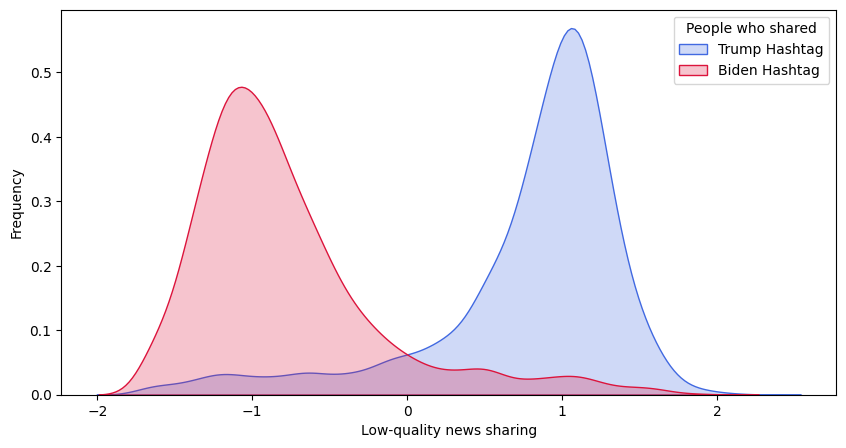

In [7]:
plt.figure(figsize=(10, 5))

# Use hue parameter to differentiate between Trump and Biden hashtags
sns.kdeplot(
    data=data,
    x='z_lowqual_pr2019_fc', 
    hue='politics_hashtag',
    fill=True,
    palette={0: '#dc143c', 1: '#4169e1'},
    alpha=0.25,
    legend=True
)

plt.xlabel('Low-quality news sharing')
plt.ylabel('Frequency')
plt.legend(title='People who shared', labels=['Trump Hashtag','Biden Hashtag'])
plt.show()

We do exactly the same steps for our second figure

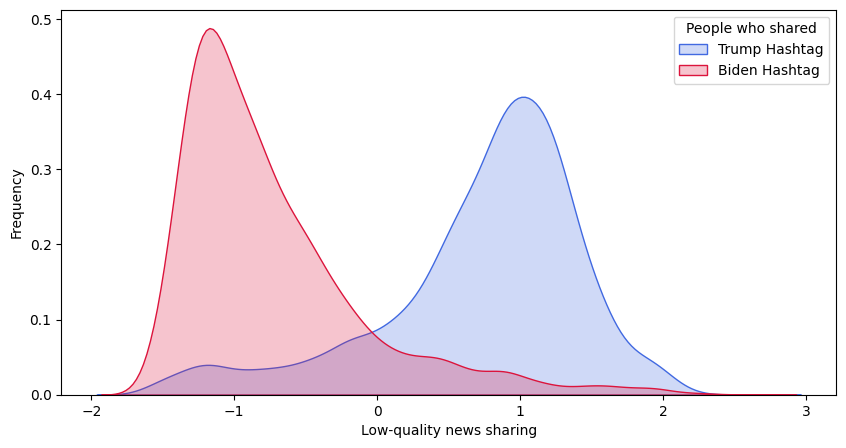

In [8]:
# Fig 1B: Tabulate 'z_lowqual_pr2019_crowd' by 'politics_hashtag'
contingency_1b = pd.crosstab(data['z_lowqual_pr2019_crowd'], data['politics_hashtag'], normalize='columns')
plt.figure(figsize=(10, 5))

# Use hue parameter to differentiate between Trump and Biden hashtags
sns.kdeplot(
    data=data,
    x='z_lowqual_pr2019_crowd', 
    hue='politics_hashtag',
    fill=True,
    palette={0: '#dc143c', 1: '#4169e1'},
    alpha=0.25,
    legend=True
)

plt.xlabel('Low-quality news sharing')
plt.ylabel('Frequency')
plt.legend(title='People who shared', labels=['Trump Hashtag','Biden Hashtag'])
plt.show()


## Low-quality News Sharing on Twitter

To examine on a quatitative manner, using a t-test, weaither `politics_hashtag` has an effect we must first set some metrics. We will add these to functions and then use them in the end to conduct our test

In [9]:
def pooled_standard_deviation(s1, s2):
    """
    Calculate the pooled standard deviation for two samples.
    
    """
    # Calculate sample standard deviations
    sd_1 = statistics.stdev(s1)
    sd_2 = statistics.stdev(s2)
    
    # Calculate sample lengths
    n1 = len(s1)
    n2 = len(s2)
    
    # Compute pooled standard deviation
    pooled_std = math.sqrt(
        ((n1 - 1) * sd_1 ** 2 + 
         (n2 - 1) * sd_2 ** 2) / 
        (n1 + n2 - 2)
    )
    
    return pooled_std

To quatify the effect size we will use Cohen's $d$ and and Hedges' $g$.

For Cohen's $d$ we use the pooled standrad deviation fuction we created above in order to calculate: $$ d = \frac{\bar{x}_{1} - \bar{x}_{2}}{s} $$

In [10]:
def cohens_d(s1, s2):
    """
    Calculate Cohen's d
    """
    # Calculate means of both groups
    mean1 = np.mean(s1)
    mean2 = np.mean(s2)
    
    # Calculate pooled standard deviation
    pooled_std = pooled_standard_deviation(s1, s2)
    
    # Calculate Cohen's d
    cohens_d = (mean1 - mean2) / pooled_std
    
    return cohens_d


And  for Hedges' $g$ we use the Cohen's $d$ we just created in order to find: $$ \Bigg(1 - \frac{3}{4  (n_1 + n_2) - 9)}\Bigg)d $$

In [11]:
def hedges_g(s1, s2):
    """
    Calculate Hedges' g
    """
    # Calculate sample lengths
    n1 = len(s1)
    n2 = len(s2)
    
    # Calculate correction factor
    correction_factor = 1 - (3 / (4 * (n1 + n2) - 9))
    
    # Calculate Hedges' g
    hedges_g = correction_factor * cohens_d(s1, s2)
    
    return hedges_g

Before continuing with out t-tests it's important to note that we assume that the populations **do not** have equal variances. It's currently the preferred approach to _not_ perform an ANOVA test before our t-test to gauge weather or not our populations are of equal variance. This is because type one errors might be inflated. Please see [here](https://doi.org/10.1348/000711004849222) and [here](https://doi.org/10.1214/09-STS301) for more information.

In [12]:
# Variables for quality metrics
metrics = [
    'lowqual_pr2019_fc', 'lowqual_afm', 'lowqual_mbfc', 
    'lowqual_lasser2019', 'lowqual_pr2019_crowd', 'lowqual_pr2019_crowdrep'
]

# Grouping variable
grouping_variable = 'politics_hashtag'

# Loop through each metric
results = []
for metric in metrics:
    # Split data into two groups based on `politics_hashtag`
    trump_group = data[data[grouping_variable] == 1][metric].dropna()
    biden_group = data[data[grouping_variable] == 0][metric].dropna()
    
    # Welch's T-test as we assume non equal variances
    t_stat, p_value = ttest_ind(trump_group, biden_group, equal_var=False) 
    
    # Calculate Cohen's d
    effect_size_d = cohens_d(trump_group, biden_group)

    # Calculate hedges's g
    effect_size_g = hedges_g(trump_group, biden_group)
    
    # Store results
    results.append({
        'Metric': metric,
        'Trump_Mean': trump_group.mean(),
        'Biden_Mean': biden_group.mean(),
        'T-Statistic': t_stat,
        'P-Value': f"{p_value:.12f}",
        'Effect_Size (Cohen\'s d)': effect_size_d,
        'Effect_Size (Hedges\'s g)': effect_size_g
    })

# Convert results to DataFrame for display
results_df = pd.DataFrame(results)

# Display results
print(results_df)


                    Metric  Trump_Mean  Biden_Mean  T-Statistic  \
0        lowqual_pr2019_fc    0.653052    0.278144   119.246476   
1              lowqual_afm    0.360563    0.190184   102.711200   
2             lowqual_mbfc    0.498072    0.328687    97.584148   
3       lowqual_lasser2019    0.641664    0.346232   102.679384   
4     lowqual_pr2019_crowd    0.690696    0.584678   102.501955   
5  lowqual_pr2019_crowdrep    0.720120    0.684697    61.083019   

          P-Value  Effect_Size (Cohen's d)  Effect_Size (Hedges's g)  
0  0.000000000000                 2.521188                  2.520977  
1  0.000000000000                 2.164878                  2.164698  
2  0.000000000000                 2.057540                  2.057369  
3  0.000000000000                 2.163831                  2.163650  
4  0.000000000000                 2.166782                  2.166601  
5  0.000000000000                 1.291464                  1.291356  


We notice that for every single metric Trump's Mean is higher than Biden's Mean while this difference is statistically significant to a great degree. Both effect size metrics (Cohen's d and Hedges's g) show a Huge effect for all metrics. Pretty conclusive I would say! 

### Sharing Lower-quality News Sources and Conservative Ideology

## News Sharing Can Help Explain Suspension, Using Single Predictors

## News Sharing Can Help Explain Suspension, Using Multiple Predictors

## Appendix

### Diagram Carbon Copy Technique

In order to make my diagrams a carbon copy of the ones in the exercise I followed the following process.\
The diagrams were given to us as svg's so I went through the structure metadata in order to find exactly the plotting used. The tag Agent shows us it was created using `Matplotlib v3.9.2` (which is the underlying agent of Seaborn too). The next thing we need are the colors used. These could be sampled from the diagram using a pixel analysis but this might give us bad results partly depending on our render or rastering. So I once again went through the svg data to find the fill styles. I found the following snipets of code:\
`" style="fill: #dc143c; fill-opacity: 0.25; stroke: #dc143c; stroke-linejoin: miter"/>`\
`" style="fill: #4169e1; fill-opacity: 0.25; stroke: #4169e1; stroke-linejoin: miter"/>`\
Which not only gave me the color hex but also the alpha of the fill.